In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from mlxtend.plotting import plot_decision_regions
from sklearn.datasets import make_moons
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PolynomialFeatures

In [2]:
# Generate Dataset

X, y = make_moons(n_samples=200, noise=0.2, random_state=7)

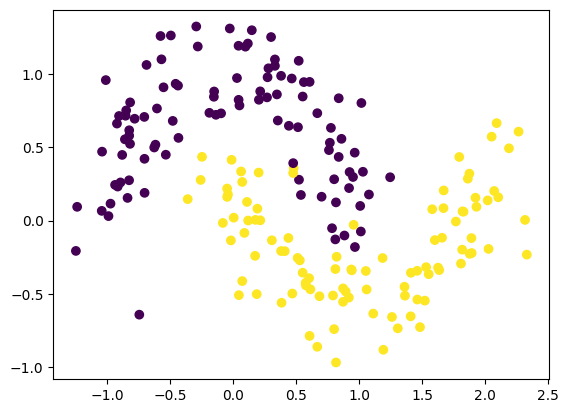

In [3]:
plt.scatter(X[:,0],X[:,1],c=y)

0.835


<Axes: >

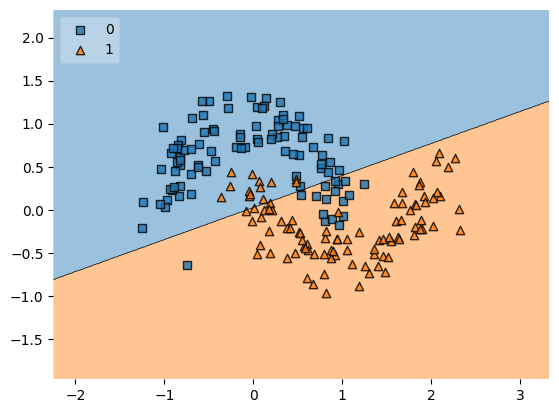

In [4]:
# without Polynomial Feature

clf = LogisticRegression()

clf.fit(X,y)

# accuracy
print(np.mean(cross_val_score(clf,X,y,scoring='accuracy',cv=10)))

plot_decision_regions(X, y.astype('int'), clf, legend=2)

In [5]:
# Apply Polynomial Feature

poly = PolynomialFeatures(degree=3,include_bias=False)
X_trf = poly.fit_transform(X)

clf1 = LogisticRegression()

print(np.mean(cross_val_score(clf1,X_trf,y,scoring='accuracy',cv=10)))

# Observation -> Accuracy Increased From 83% to 93%

0.9349999999999999


In [6]:
# Function to Implement Different Different Degree Of Polynomial

def plot_decision_boundary(X,y,degree=1):
    
    poly = PolynomialFeatures(degree=degree)
    X_trf = poly.fit_transform(X)
    
    clf = LogisticRegression()
    clf.fit(X_trf,y)
    
    accuracy = np.mean(cross_val_score(clf,X_trf,y,scoring='accuracy',cv=10))
    
    a=np.arange(start=X[:,0].min()-1, stop=X[:,0].max()+1, step=0.01)
    b=np.arange(start=X[:,1].min()-1, stop=X[:,1].max()+1, step=0.01)


    XX,YY=np.meshgrid(a,b)
    
    input_array=np.array([XX.ravel(),YY.ravel()]).T

    labels=clf.predict(poly.transform(input_array))
    
    plt.contourf(XX,YY,labels.reshape(XX.shape),alpha=0.5)
    plt.scatter(X[:,0],X[:,1], c=y)
    plt.title('Degree = {}, accuracy is {}'.format(degree,np.round(accuracy,4)))

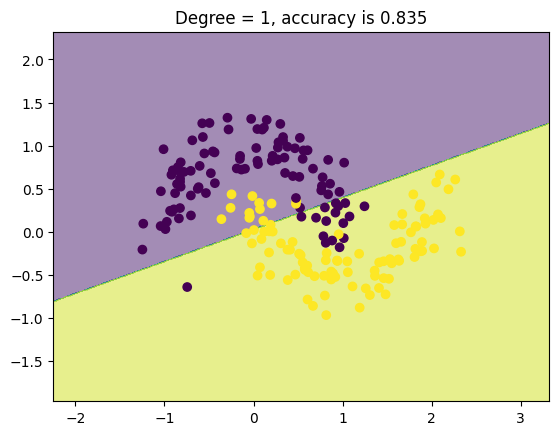

In [7]:
# Implement and Plot for Different Degree

# No Degree -> Normal Logistic Regression

plot_decision_boundary(X,y)

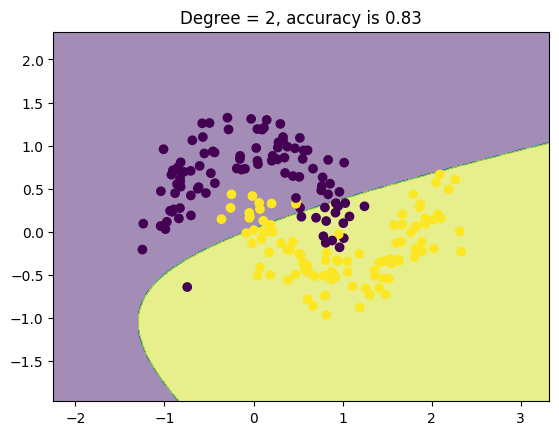

In [8]:
plot_decision_boundary(X,y,degree=2)

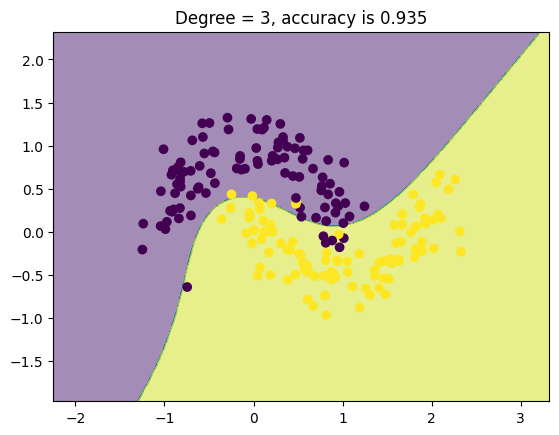

In [9]:
plot_decision_boundary(X,y,degree=3)

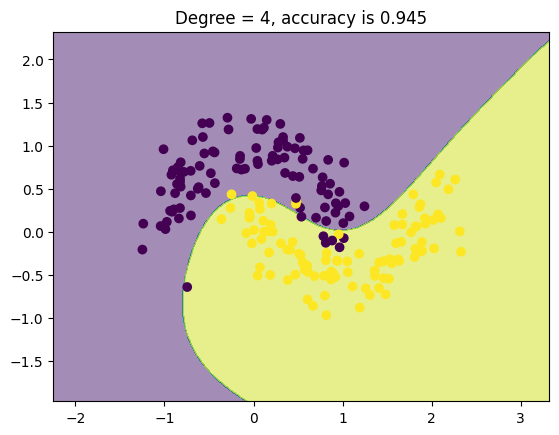

In [10]:
plot_decision_boundary(X,y,degree=4)

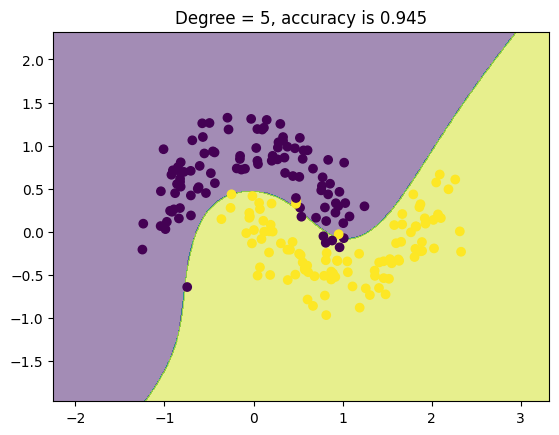

In [11]:
plot_decision_boundary(X,y,degree=5)

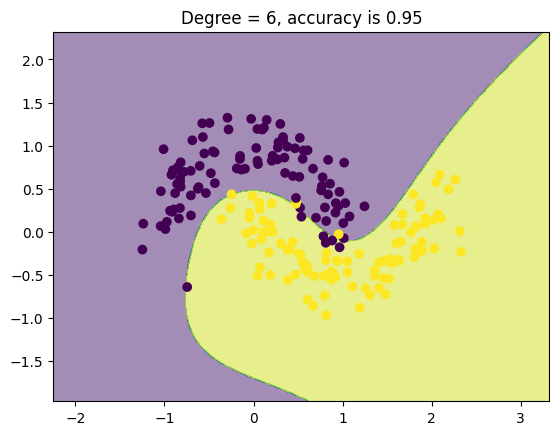

In [12]:
plot_decision_boundary(X,y,degree=6)

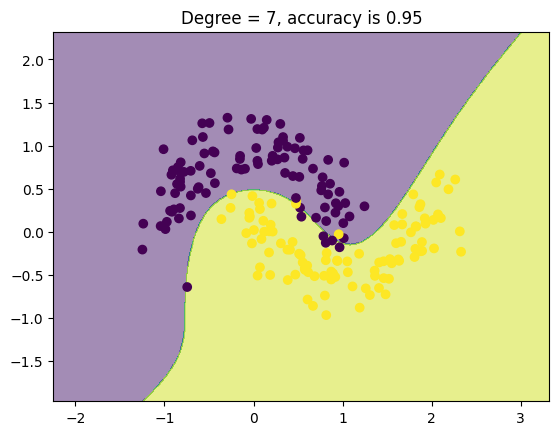

In [13]:
plot_decision_boundary(X,y,degree=7)

C:\Users\parij\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


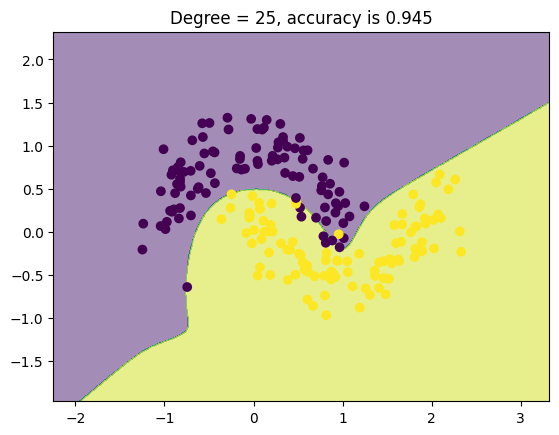

In [14]:
# Case Of Over Fitting

plot_decision_boundary(X,y,degree=25)